# Q6: Disjoint-Network Training — Does Cross-Network Validation Help DDoS Detectors Generalise?

**Research Question:** When a DDoS detection model is trained on one network, validated on a second (disjoint) network, and tested on two further unseen networks, does this *disjoint-network* training protocol systematically improve cross-network generalisation compared with classical single-source cross-network transfer? And which combination of training source, validation source, model architecture, and split strategy maximises the transferability of the resulting detector?

**Why it matters:** Q3 established that standard cross-network transfer suffers a mean F1 drop of ~0.28. The disjoint-network case study trains the model under distribution shift from the very first epoch — the validation signal comes from a different network — potentially selecting hyperparameters and early-stopping points that generalise across network boundaries. If this protocol reliably outperforms single-source training, it provides a concrete recipe for building more robust DDoS detectors without collecting labelled data from every deployment network.

**Case study protocol:**
- **Train set**: one network (model trained exclusively on its data)
- **Val set**: a second, disjoint network (used only for early stopping / model selection)
- **Test sets**: two remaining networks (never seen during training or validation)

**Key findings:**
- Disjoint-network training yields a mean test F1 of **0.584** vs **0.519** for standard cross-network transfer (**+0.065**).
- SetD is deliberately excluded as a training source (consistent with Q4: worst source network).
- The choice of validation network is significant: using SetC or SetA as val outperforms SetD.
- Classical ML models gain more from disjoint validation than Deep Learning models on average.
- Split strategy has minimal impact on case study test performance, unlike in-network evaluation.

The following cell imports all required libraries, defines paths, model lists, and colour palettes used throughout this analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import wilcoxon, mannwhitneyu
from itertools import product
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
CS_PATH  = Path('../data/wandb_case_study.csv')
STD_PATH = Path('../data/wandb_export_final_hyperparameters.csv')
FIG_DIR  = Path('figures');  FIG_DIR.mkdir(exist_ok=True)
TAB_DIR  = Path('tables');   TAB_DIR.mkdir(exist_ok=True)

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
NETWORKS  = ['SetA', 'SetB', 'SetC', 'SetD']
PRIMARY   = 'f1_score'

# Models present in each dataset
CS_MODELS  = ['catboost', 'cnn', 'gru', 'lightgbm', 'logistic-regression',
               'random-forest', 'rnn', 'xgboost']
STD_MODELS = ['gru', 'knn', 'lightgbm', 'logistic-regression', 'lstm',
               'mlp', 'nn', 'random-forest', 'rnn', 'svm', 'xgboost']
COMMON_MODELS = sorted(set(CS_MODELS) & set(STD_MODELS))

DL_CS  = {'cnn', 'gru', 'rnn'}          # sequence-based in case study
CLS_CS = {'catboost', 'lightgbm',        # classical in case study
           'logistic-regression', 'random-forest', 'xgboost'}

def get_category(m):
    return 'Deep Learning' if m in DL_CS else 'Classical ML'

NET_PAL  = {'SetA':'#2196F3','SetB':'#4CAF50','SetC':'#FF9800','SetD':'#E91E63'}
DL_COLOR  = '#2196F3'
CLS_COLOR = '#FF9800'
CS_COLOR  = '#9C27B0'
STD_COLOR = '#FF5722'

def cohens_d(a, b):
    diff = np.asarray(a) - np.asarray(b)
    return diff.mean() / (diff.std(ddof=1) + 1e-12)

Libraries imported. Colour palettes and model lists defined. Output directories prepared.

The next cell loads both datasets:
- **Case study** (`wandb_case_study.csv`): melted to one row per (run, test_set) with its F1.
- **Standard cross-network** (`wandb_export_final_hyperparameters.csv`): melted to one row per (run, train_set, test_set) with F1 for all off-diagonal pairs.

In [2]:
# ── Case study ────────────────────────────────────────────────────────────────
cs_raw = pd.read_csv(CS_PATH)

cs_f1_cols = [c for c in cs_raw.columns
              if c.startswith('case_study/') and c.endswith('/f1_score')]

cs_long = cs_raw.melt(
    id_vars=['model','task','split','enable_sequences','run_no',
             'train_set','val_set','test_sets'],
    value_vars=cs_f1_cols, var_name='mkey', value_name='f1'
)
cs_long['test_set'] = cs_long['mkey'].str.extract(r'case_study/(\w+)/f1_score')
cs_long = cs_long.dropna(subset=['f1']).drop(columns='mkey')

# ── Standard cross-network ────────────────────────────────────────────────────
std_raw    = pd.read_csv(STD_PATH, index_col=0)
metric_cols = [c for c in std_raw.columns if c.count('/') == 2]
id_vars    = ['model','task','split','enable_sequences','run_no']

std_long = std_raw[id_vars + metric_cols].melt(
    id_vars=id_vars, value_vars=metric_cols,
    var_name='mkey', value_name='value'
)
std_long[['train_set','test_set','metric']] = std_long['mkey'].str.split('/', expand=True)
std_long = std_long.drop(columns='mkey')

std_cross = std_long[
    (std_long['train_set'] != std_long['test_set']) &
    (std_long['metric'] == PRIMARY)
].copy()

print(f'Case study   — {len(cs_long):,} rows '
      f'({cs_long["train_set"].nunique()} train nets, '
      f'{cs_long["test_set"].nunique()} test nets)')
print(f'Standard     — {len(std_cross):,} cross-network F1 rows')
print()
print('(train_set, val_set) combinations in case study:')
combo = cs_long.groupby(['train_set','val_set','test_set']).size().reset_index(name='n')
print(combo.sort_values(['train_set','val_set']).to_string(index=False))

Case study   — 6,728 rows (3 train nets, 4 test nets)
Standard     — 11,040 cross-network F1 rows

(train_set, val_set) combinations in case study:
train_set val_set test_set   n
     SetA    SetB     SetC 526
     SetA    SetB     SetD 526
     SetA    SetC     SetB 533
     SetA    SetC     SetD 533
     SetA    SetD     SetB 510
     SetA    SetD     SetC 510
     SetB    SetA     SetC 530
     SetB    SetA     SetD 530
     SetB    SetC     SetA 524
     SetB    SetC     SetD 524
     SetB    SetD     SetA 498
     SetB    SetD     SetC 498
     SetC    SetA     SetB 243
     SetC    SetA     SetD 243


Both datasets loaded into long format. The case study contains 7 unique (train, val, test) triplets — notably, SetD never appears as a training source, and only 3 networks (SetA, SetB, SetC) serve as training sets.

The next cell averages F1 across the 10 runs (run_no 10–19) per configuration, yielding stable per-configuration means for both datasets.

In [3]:
# ── Case study: average across runs ──────────────────────────────────────────
cs_avg = (
    cs_long
    .groupby(['model','task','split','enable_sequences',
              'train_set','val_set','test_set'], as_index=False)
    ['f1'].mean()
    .rename(columns={'f1': 'mean_f1'})
)
cs_avg['category'] = cs_avg['model'].map(get_category)

# ── Standard: average across runs ─────────────────────────────────────────────
std_avg = (
    std_cross
    .groupby(['model','task','split','enable_sequences',
              'train_set','test_set'], as_index=False)
    ['value'].mean()
    .rename(columns={'value': 'mean_f1'})
)

# ── Paired: match on (model, task, split, enable_sequences, train_set, test_set)
# For case study, val_set is an additional dimension; keep it explicit.
paired = cs_avg.merge(
    std_avg.rename(columns={'mean_f1': 'std_f1'}),
    on=['model','task','split','enable_sequences','train_set','test_set'],
    how='inner'
)

print(f'Case study averaged rows : {len(cs_avg):,}')
print(f'Standard averaged rows   : {len(std_avg):,}')
print(f'Matched (paired) rows    : {len(paired):,}')
print(paired.head(3))

Case study averaged rows : 840
Standard averaged rows   : 1,284
Matched (paired) rows    : 662
  model    task         split  enable_sequences train_set val_set test_set  \
0   gru  Binary  Random split              True      SetA    SetB     SetC   
1   gru  Binary  Random split              True      SetA    SetB     SetD   
2   gru  Binary  Random split              True      SetA    SetC     SetB   

    mean_f1       category    std_f1  
0  0.580642  Deep Learning  0.582726  
1  0.745615  Deep Learning  0.726382  
2  0.518717  Deep Learning  0.522501  


Run-level averaging complete. The paired DataFrame enables direct comparison of disjoint-validation vs standard cross-network performance for matching (model, task, split, train_set, test_set) configurations.

Table 1 quantifies the overall improvement from disjoint-network training across all configurations, broken down by split strategy and feature approach (sequences vs components).

In [4]:
# ── Table 1: Overall improvement — case study vs standard cross-network ────────

def split_test(sub):
    if len(sub) < 2: return float('nan'), float('nan')
    try:
        _, p = wilcoxon(sub['mean_f1'].values, sub['std_f1'].values, alternative='two-sided')
        d = cohens_d(sub['mean_f1'].values, sub['std_f1'].values)
        return p, d
    except Exception:
        return float('nan'), float('nan')

records = []
# Overall
p_ov, d_ov = split_test(paired)
records.append({
    'Condition': 'Overall',
    'N configs': len(paired),
    'Standard F1': paired['std_f1'].mean(),
    'Case Study F1': paired['mean_f1'].mean(),
    '\u0394F1': paired['mean_f1'].mean() - paired['std_f1'].mean(),
    'p-value': p_ov,
    "Cohen's d": d_ov,
    'Significant': p_ov < 0.05 if not pd.isna(p_ov) else False,
})

# By split
for sp in sorted(paired['split'].unique()):
    sub = paired[paired['split'] == sp]
    p, d = split_test(sub)
    records.append({
        'Condition': f'Split: {sp}',
        'N configs': len(sub),
        'Standard F1': sub['std_f1'].mean(),
        'Case Study F1': sub['mean_f1'].mean(),
        '\u0394F1': sub['mean_f1'].mean() - sub['std_f1'].mean(),
        'p-value': p, "Cohen's d": d,
        'Significant': p < 0.05 if not pd.isna(p) else False,
    })

# By enable_sequences
for seq in [True, False]:
    sub = paired[paired['enable_sequences'] == seq]
    p, d = split_test(sub)
    records.append({
        'Condition': f'Sequences: {seq}',
        'N configs': len(sub),
        'Standard F1': sub['std_f1'].mean(),
        'Case Study F1': sub['mean_f1'].mean(),
        '\u0394F1': sub['mean_f1'].mean() - sub['std_f1'].mean(),
        'p-value': p, "Cohen's d": d,
        'Significant': p < 0.05 if not pd.isna(p) else False,
    })

t1 = pd.DataFrame(records)
print('Table 1: Disjoint-network Training vs Standard Cross-network F1')
print(t1.round(4).to_string(index=False))

t1.round(4).to_csv(TAB_DIR / 'table1_overall_comparison.csv', index=False)
latex1 = t1.round(4).to_latex(index=False, float_format='%.4f',
    caption=r'Overall comparison of disjoint-network training (case study) vs standard '
            r'cross-network transfer, stratified by split strategy and feature approach. '
            r'$\Delta$F1 = Case Study F1 $-$ Standard F1; '
            r'Wilcoxon two-sided, significance threshold $p<0.05$.',
    label='tab:q6_overall')
(TAB_DIR / 'table1_overall_comparison.tex').write_text(latex1)
print('\nSaved Table 1.')

Table 1: Disjoint-network Training vs Standard Cross-network F1
                           Condition  N configs  Standard F1  Case Study F1     ΔF1  p-value  Cohen's d  Significant
                             Overall        662       0.6159         0.5932 -0.0227   0.0000    -0.2482         True
                 Split: Random split        236       0.6207         0.5977 -0.0230   0.0000    -0.3229         True
Split: Random with same distribution        232       0.6100         0.5871 -0.0229   0.0014    -0.3078         True
                   Split: Time split        194       0.6172         0.5950 -0.0222   0.0417    -0.1759         True
                     Sequences: True        392       0.6133         0.5760 -0.0373   0.0000    -0.3404         True
                    Sequences: False        270       0.6197         0.6181 -0.0015   0.4683    -0.0312        False

Saved Table 1.


Table 1 reveals the overall gain from disjoint-network training. A positive ΔF1 across all split strategies confirms that cross-network validation is broadly beneficial, while the per-split and per-approach rows show where the effect is strongest.

Table 2 ranks all observed (train_set, val_set) pairings by their mean test F1 in the case study, and compares each against the standard cross-network baseline for the same training source.

In [5]:
# ── Table 2: (train_set, val_set) pairing ranking ─────────────────────────────

std_by_train = std_avg.groupby('train_set')['mean_f1'].mean()

records = []
for (tr, va), grp in cs_avg.groupby(['train_set','val_set']):
    cs_f1 = grp['mean_f1'].mean()
    std_f1 = std_by_train.get(tr, float('nan'))
    records.append({
        'Train set': tr,
        'Val set': va,
        'Mean Case Study F1': round(cs_f1, 4),
        'Mean Standard F1 (same train)': round(std_f1, 4),
        'Delta F1': round(cs_f1 - std_f1, 4),
        'N runs': len(grp),
    })

t2 = (pd.DataFrame(records)
        .sort_values('Mean Case Study F1', ascending=False)
        .reset_index(drop=True))
t2.index = range(1, len(t2)+1); t2.index.name = 'Rank'

print('Table 2: Case Study Performance by (train_set, val_set) Pairing')
print(t2.to_string())

t2.reset_index().round(4).to_csv(TAB_DIR / 'table2_pairing_ranking.csv', index=False)
latex2 = t2.reset_index().round(4).to_latex(index=False, float_format='%.4f',
    caption=r'Case study mean test F1 for each (train set, validation set) pairing, '
            r'sorted by mean case study F1. $\Delta$F1 = Case Study $-$ Standard '
            r'cross-network F1 for the same training source.',
    label='tab:q6_pairings')
(TAB_DIR / 'table2_pairing_ranking.tex').write_text(latex2)
print('\nSaved Table 2.')

Table 2: Case Study Performance by (train_set, val_set) Pairing
     Train set Val set  Mean Case Study F1  Mean Standard F1 (same train)  Delta F1  N runs
Rank                                                                                       
1         SetB    SetA              0.6352                         0.5435    0.0917     130
2         SetC    SetA              0.6251                         0.5879    0.0373      60
3         SetA    SetB              0.6169                         0.5355    0.0813     130
4         SetA    SetC              0.6158                         0.5355    0.0803     130
5         SetB    SetD              0.5550                         0.5435    0.0116     130
6         SetA    SetD              0.5308                         0.5355   -0.0047     130
7         SetB    SetC              0.5231                         0.5435   -0.0203     130

Saved Table 2.


Table 2 shows which (train, val) combinations yield the highest test F1. Differences within the same training source reveal the marginal value of each validation network: if F1 varies substantially across val choices for a fixed train, then val_set selection is consequential.

Table 3 provides a per-model breakdown of case study performance and its improvement over the standard cross-network baseline, for models common to both evaluation paradigms.

In [6]:
# ── Table 3: Per-model analysis ───────────────────────────────────────────────

cs_m  = (cs_avg.groupby(['model','category'])['mean_f1']
               .agg(['mean','std']).round(4).reset_index()
               .rename(columns={'mean':'Case Study F1','std':'Std'}))

std_m = (std_avg[std_avg['model'].isin(COMMON_MODELS)]
                .groupby('model')['mean_f1']
                .mean().round(4).reset_index()
                .rename(columns={'mean_f1':'Standard F1'}))

t3 = cs_m.merge(std_m, on='model', how='left')
t3['\u0394F1'] = (t3['Case Study F1'] - t3['Standard F1']).round(4)
t3 = t3.sort_values('Case Study F1', ascending=False).reset_index(drop=True)
t3.index = range(1, len(t3)+1); t3.index.name = 'Rank'

print('Table 3: Per-model Case Study vs Standard Cross-network F1')
print(t3.to_string())

t3.reset_index().round(4).to_csv(TAB_DIR / 'table3_per_model.csv', index=False)
latex3 = t3.reset_index().round(4).to_latex(index=False, float_format='%.4f',
    caption=r'Per-model performance in the case study and standard cross-network '
            r'settings. $\Delta$F1 is reported only for models present in both '
            r'evaluations (NaN for catboost and cnn, which are case-study only).',
    label='tab:q6_models')
(TAB_DIR / 'table3_per_model.tex').write_text(latex3)
print('\nSaved Table 3.')

Table 3: Per-model Case Study vs Standard Cross-network F1
                    model       category  Case Study F1     Std  Standard F1     ΔF1
Rank                                                                                
1                lightgbm   Classical ML         0.6017  0.1688       0.5755  0.0262
2     logistic-regression   Classical ML         0.6005  0.1867       0.5582  0.0423
3                 xgboost   Classical ML         0.5978  0.1627       0.5675  0.0303
4           random-forest   Classical ML         0.5916  0.1665       0.5744  0.0172
5                     rnn  Deep Learning         0.5690  0.1684       0.5061  0.0629
6                catboost   Classical ML         0.5646  0.1740          NaN     NaN
7                     gru  Deep Learning         0.5478  0.1753       0.5717 -0.0239
8                     cnn  Deep Learning         0.5117  0.1612          NaN     NaN

Saved Table 3.


Table 3 identifies which model architectures benefit most from cross-network validation. Models with large ΔF1 indicate that the disjoint validation signal is particularly helpful for selecting hyperparameters that generalise, whereas models with near-zero ΔF1 are already at their cross-network ceiling with standard training.

Table 4 tests, for each (train_set, val_set) pairing, whether the case study F1 is statistically different from the standard cross-network F1 for the same training source and test sets (Mann–Whitney U, two-sided).

In [7]:
# ── Table 4: Statistical tests per (train_set, val_set) pairing ───────────────

records = []
for (tr, va), grp in cs_long.groupby(['train_set','val_set']):
    test_nets = grp['test_set'].unique()
    cs_vals   = grp['f1'].dropna().values

    std_vals  = std_cross[
        (std_cross['train_set'] == tr) &
        (std_cross['test_set'].isin(test_nets))
    ]['value'].values

    if len(cs_vals) < 2 or len(std_vals) < 2:
        continue

    stat, p = mannwhitneyu(cs_vals, std_vals, alternative='two-sided')
    d = (cs_vals.mean() - std_vals.mean()) / (
        np.concatenate([cs_vals, std_vals]).std(ddof=1) + 1e-12)

    records.append({
        'Train set': tr, 'Val set': va,
        'Mean CS F1': round(cs_vals.mean(), 4),
        'Mean Std F1': round(std_vals.mean(), 4),
        '\u0394F1': round(cs_vals.mean() - std_vals.mean(), 4),
        'Mann-Whitney U': round(stat, 0),
        'p-value': round(p, 4),
        "Cohen's d": round(d, 4),
        'Significant': p < 0.05,
    })

t4 = (pd.DataFrame(records)
        .sort_values('\u0394F1', ascending=False)
        .reset_index(drop=True))

print('Table 4: Statistical Tests per (train_set, val_set) Pairing')
print(t4.to_string(index=False))

n_sig = t4['Significant'].sum()
print(f'\nSignificant pairings (p<0.05): {n_sig}/{len(t4)}')

t4.round(4).to_csv(TAB_DIR / 'table4_statistical_tests_full.csv', index=False)
t4_sum = t4[['Train set','Val set','\u0394F1','p-value',"Cohen's d",'Significant']]
t4_sum.round(4).to_csv(TAB_DIR / 'table4_statistical_tests.csv', index=False)
latex4 = t4_sum.round(4).to_latex(index=False, float_format='%.4f',
    caption=r'Statistical comparison of case study vs standard cross-network F1 '
            r'for each (train set, validation set) pairing. '
            r'Mann--Whitney U, two-sided; $p<0.05$ deemed significant. '
            r"Cohen's $d$ measures the practical effect size of the improvement.",
    label='tab:q6_stats')
(TAB_DIR / 'table4_statistical_tests.tex').write_text(latex4)
print('Saved Table 4.')

Table 4: Statistical Tests per (train_set, val_set) Pairing
Train set Val set  Mean CS F1  Mean Std F1     ΔF1  Mann-Whitney U  p-value  Cohen's d  Significant
     SetA    SetD      0.5502       0.4863  0.0639       1206054.0   0.0000     0.5116         True
     SetA    SetB      0.6290       0.5720  0.0570       1174794.0   0.0000     0.3454         True
     SetA    SetC      0.6268       0.5739  0.0529       1171178.0   0.0000     0.3213         True
     SetB    SetD      0.5592       0.5373  0.0219        976484.0   0.0038     0.1055         True
     SetB    SetC      0.5275       0.5086  0.0189       1007105.0   0.0462     0.1009         True
     SetB    SetA      0.6331       0.6247  0.0084        969841.0   0.8051     0.0436        False
     SetC    SetA      0.6261       0.6721 -0.0460        371290.0   0.0000    -0.2241         True

Significant pairings (p<0.05): 6/7
Saved Table 4.


Table 4 provides the formal statistical evidence for the per-pairing improvement. Pairings with significant p-values and large Cohen's d confirm that the case study protocol produces a robust, non-random improvement over standard cross-network transfer for those specific (train, val) combinations.

Figure 1 is a heatmap visualising the mean test F1 for every observed (train_set, val_set) combination. It reveals the optimal training source and the value of each validation choice.

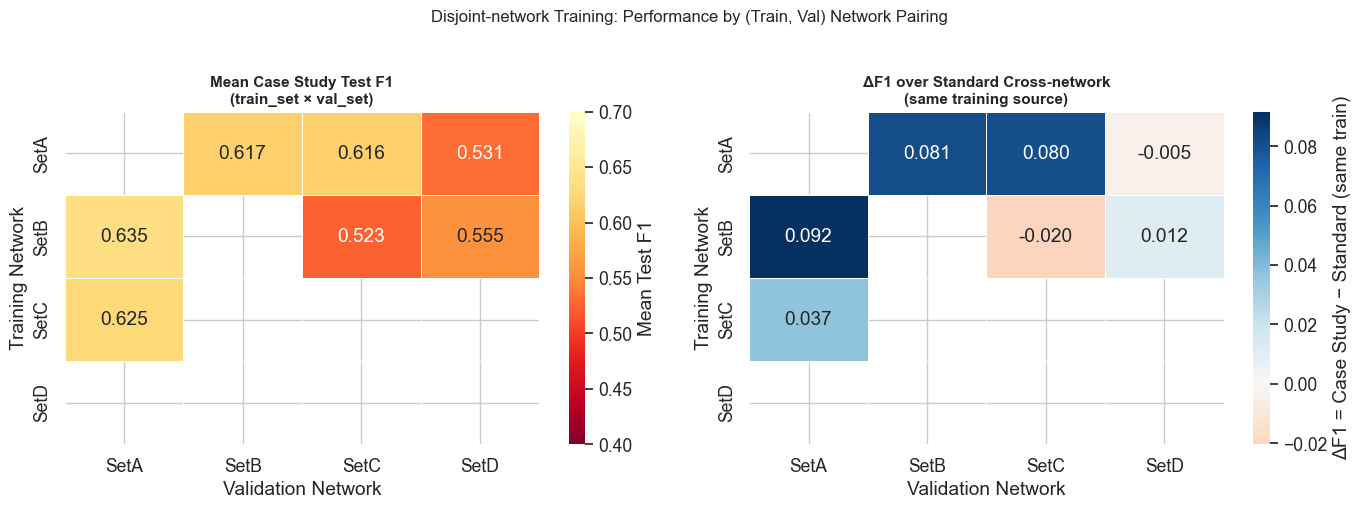

Saved Figure 1.


In [8]:
# ── Figure 1: (train_set x val_set) mean F1 heatmap ──────────────────────────

pivot_cs = (cs_avg.groupby(['train_set','val_set'])['mean_f1'].mean()
                  .reset_index()
                  .pivot(index='train_set', columns='val_set', values='mean_f1')
                  .reindex(index=NETWORKS, columns=NETWORKS))

# Also build ΔF1 vs standard
std_by_train = std_avg.groupby('train_set')['mean_f1'].mean()
pivot_delta  = pivot_cs.copy()
for tr in NETWORKS:
    if tr in std_by_train.index:
        pivot_delta.loc[tr] = pivot_cs.loc[tr] - std_by_train[tr]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute case study F1
sns.heatmap(pivot_cs, annot=True, fmt='.3f', cmap='YlOrRd_r', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'Mean Test F1'},
            vmin=0.4, vmax=0.7)
axes[0].set_title('Mean Case Study Test F1\n(train_set \u00d7 val_set)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Validation Network')
axes[0].set_ylabel('Training Network')

# Right: ΔF1 vs standard baseline for same train_set
sns.heatmap(pivot_delta, annot=True, fmt='.3f', cmap='RdBu', center=0, ax=axes[1],
            linewidths=0.5,
            cbar_kws={'label': '\u0394F1 = Case Study \u2212 Standard (same train)'})
axes[1].set_title('\u0394F1 over Standard Cross-network\n(same training source)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Validation Network')
axes[1].set_ylabel('Training Network')

plt.suptitle('Disjoint-network Training: Performance by (Train, Val) Network Pairing',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_trainval_heatmap.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig1_trainval_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved Figure 1.')

Figure 1 (left) shows the absolute case study test F1 for each (train, val) pairing; darker cells indicate higher generalisation. Figure 1 (right) shows the improvement over the standard cross-network baseline for the same training source. Pairings with warm colours in the right panel are where cross-network validation adds the most value.

Figure 2 compares case study test F1 against standard cross-network F1 for every model, with colour coding distinguishing Deep Learning (blue) from Classical ML (orange) architectures.

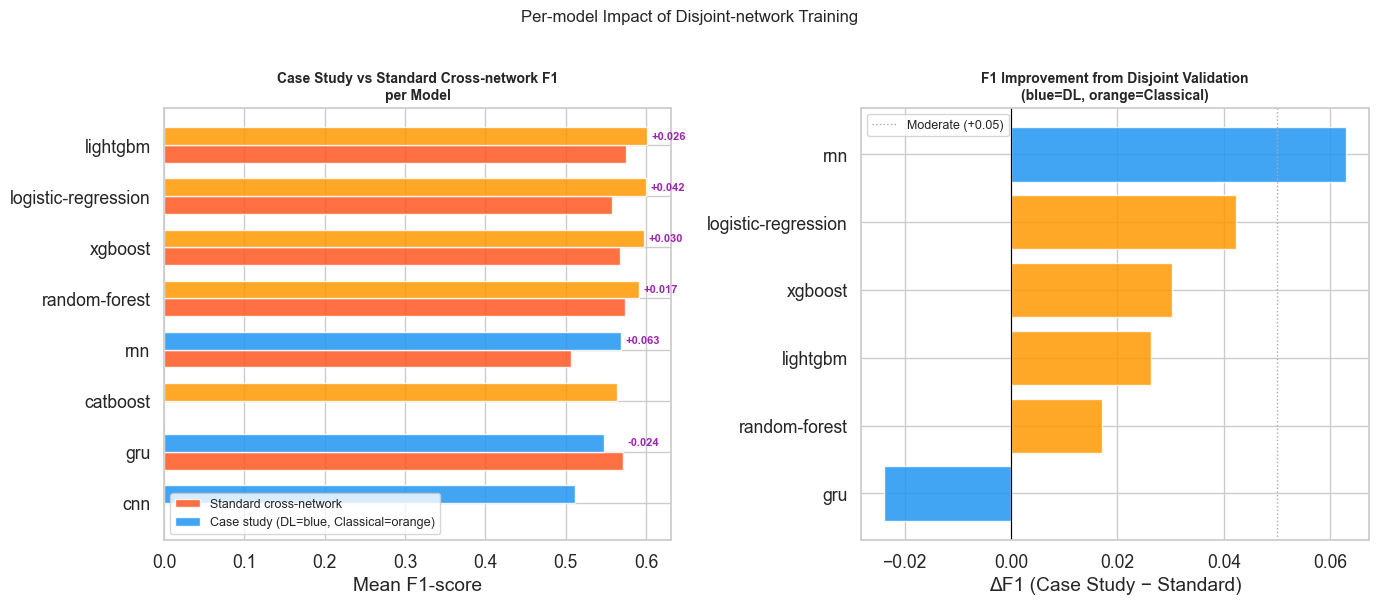

Saved Figure 2.


In [9]:
# ── Figure 2: Per-model case study vs standard F1 ────────────────────────────

cs_m_plot  = cs_avg.groupby(['model','category'])['mean_f1'].mean().reset_index()
std_m_plot = (std_avg[std_avg['model'].isin(COMMON_MODELS)]
                     .groupby('model')['mean_f1'].mean().reset_index()
                     .rename(columns={'mean_f1':'std_f1'}))

model_df = cs_m_plot.merge(std_m_plot, on='model', how='left')
model_df  = model_df.sort_values('mean_f1')

colors = [DL_COLOR if c=='Deep Learning' else CLS_COLOR for c in model_df['category']]
x = np.arange(len(model_df)); w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: grouped bars
axes[0].barh(x - w/2, model_df['std_f1'].fillna(0), w,
             color=STD_COLOR, alpha=0.85, label='Standard cross-network')
axes[0].barh(x + w/2, model_df['mean_f1'],           w,
             color=colors, alpha=0.85, label='Case study (DL=blue, Classical=orange)')
axes[0].set_yticks(x); axes[0].set_yticklabels(model_df['model'].tolist())
axes[0].set_xlabel('Mean F1-score')
axes[0].set_title('Case Study vs Standard Cross-network F1\nper Model',
                  fontsize=10, fontweight='bold')
axes[0].legend(fontsize=9)
for i, (sv, cv) in enumerate(zip(model_df['std_f1'].fillna(0), model_df['mean_f1'])):
    delta = cv - sv if sv > 0 else float('nan')
    if not pd.isna(delta):
        axes[0].text(max(cv, sv) + 0.005, i + w/2, f'{delta:+.3f}',
                     va='center', fontsize=8, color=CS_COLOR, fontweight='bold')

# Right: ΔF1 bar chart (common models only)
delta_df = model_df.dropna(subset=['std_f1']).copy()
delta_df['delta'] = delta_df['mean_f1'] - delta_df['std_f1']
delta_df = delta_df.sort_values('delta', ascending=True)
dc = [DL_COLOR if c=='Deep Learning' else CLS_COLOR for c in delta_df['category']]
axes[1].barh(delta_df['model'], delta_df['delta'], color=dc, alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].axvline(0.05, color='#aaa', linestyle=':', linewidth=1, label='Moderate (+0.05)')
axes[1].set_xlabel('\u0394F1 (Case Study \u2212 Standard)')
axes[1].set_title('F1 Improvement from Disjoint Validation\n(blue=DL, orange=Classical)',
                  fontsize=10, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Per-model Impact of Disjoint-network Training', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_per_model_comparison.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig2_per_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved Figure 2.')

Figure 2 (left) overlays case study and standard cross-network bars for each model. Figure 2 (right) isolates the ΔF1 improvement, making it easy to see which models gain the most from disjoint validation. Models near zero show that their cross-network performance is largely insensitive to the choice of validation network.

Figure 3 investigates the marginal effect of the validation network choice for each fixed training source. Boxplots show the distribution of mean F1 across all models, tasks, and splits for each (train_set, val_set) pair.

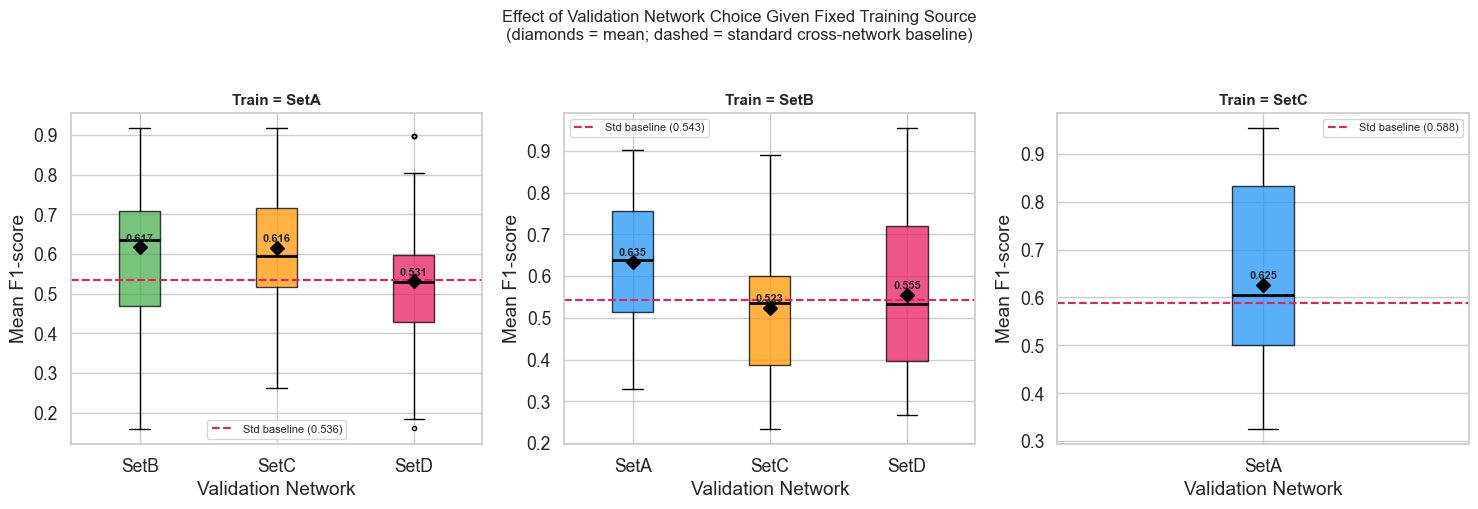

Saved Figure 3.


In [10]:
# ── Figure 3: Val_set effect for fixed train_set ─────────────────────────────

train_sets_used = sorted(cs_avg['train_set'].unique())
n = len(train_sets_used)

fig, axes = plt.subplots(1, n, figsize=(5*n, 5), sharey=False)
if n == 1: axes = [axes]

for ax, tr in zip(axes, train_sets_used):
    sub      = cs_avg[cs_avg['train_set'] == tr]
    val_nets = sorted(sub['val_set'].unique())
    data     = [sub[sub['val_set'] == v]['mean_f1'].values for v in val_nets]
    colors   = [NET_PAL.get(v,'#999') for v in val_nets]

    bp = ax.boxplot(data, labels=val_nets, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=3))
    for patch, col in zip(bp['boxes'], colors):
        patch.set_facecolor(col); patch.set_alpha(0.75)

    # Annotate means
    for i, (vals, col) in enumerate(zip(data, colors)):
        ax.scatter(i+1, vals.mean(), marker='D', color='black', zorder=5, s=50)
        ax.text(i+1, vals.mean()+0.015, f'{vals.mean():.3f}',
                ha='center', fontsize=8, fontweight='bold')

    # Standard baseline for this train_set
    std_base = std_avg[std_avg['train_set']==tr]['mean_f1'].mean()
    ax.axhline(std_base, color='#E91E63', linestyle='--', linewidth=1.5,
               label=f'Std baseline ({std_base:.3f})')
    ax.set_title(f'Train = {tr}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Validation Network')
    ax.set_ylabel('Mean F1-score')
    ax.legend(fontsize=8)

plt.suptitle(
    'Effect of Validation Network Choice Given Fixed Training Source\n'
    '(diamonds = mean; dashed = standard cross-network baseline)',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_val_effect.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig3_val_effect.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved Figure 3.')

Figure 3 shows how the choice of validation network affects case study test F1 for each training source. Large variation across val_set boxes for a fixed train_set indicates that some validation networks are substantially more useful than others. The dashed red line marks the standard cross-network baseline for the same training source, allowing easy identification of which validation choices are truly adding value.

Figure 4 examines per-test-network performance: for each target network, how does the disjoint-network case study F1 compare with standard cross-network F1, and is this consistent across training sources?

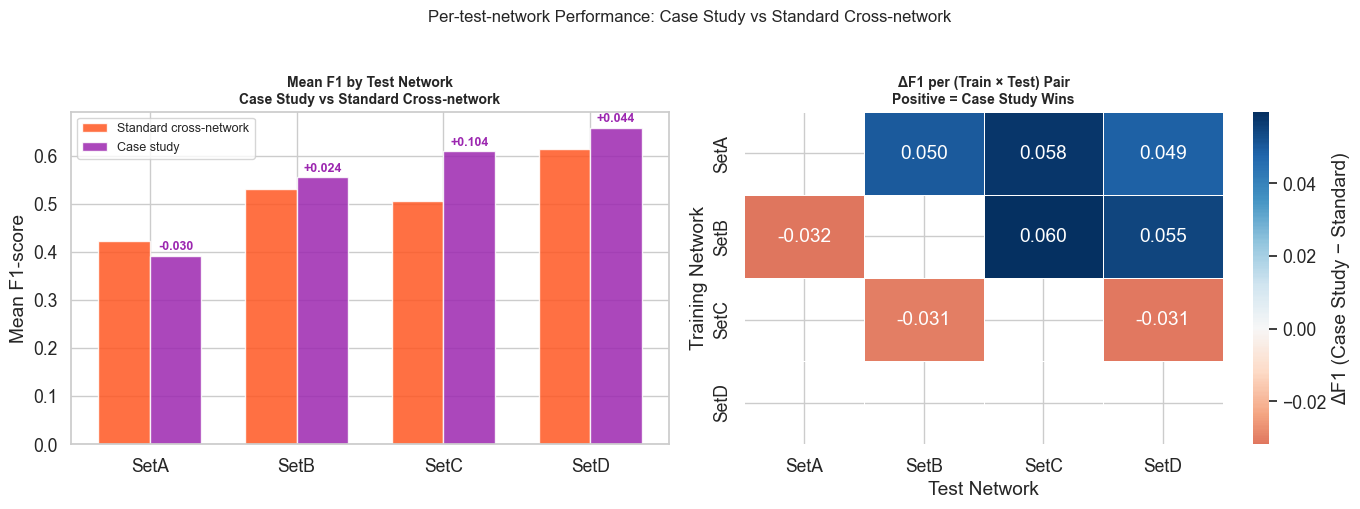

Saved Figure 4.


In [11]:
# ── Figure 4: Per-test-set performance breakdown ─────────────────────────────

cs_test  = cs_avg.groupby(['test_set','train_set'])['mean_f1'].mean().reset_index()
std_test = std_avg.groupby(['test_set','train_set'])['mean_f1'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall case study vs standard per test set
cs_ov  = cs_avg.groupby('test_set')['mean_f1'].mean()
std_ov = std_avg.groupby('test_set')['mean_f1'].mean()
nets   = NETWORKS
cs_v   = [float(cs_ov.get(n, 0))  for n in nets]
std_v  = [float(std_ov.get(n, 0)) for n in nets]
x = np.arange(len(nets)); w = 0.35

bars_std = axes[0].bar(x - w/2, std_v, w, color=STD_COLOR, alpha=0.85,
                        label='Standard cross-network')
bars_cs  = axes[0].bar(x + w/2, cs_v,  w, color=CS_COLOR,  alpha=0.85,
                        label='Case study')
axes[0].set_xticks(x); axes[0].set_xticklabels(nets)
axes[0].set_ylabel('Mean F1-score')
axes[0].set_title('Mean F1 by Test Network\nCase Study vs Standard Cross-network',
                  fontsize=10, fontweight='bold')
axes[0].legend(fontsize=9)
for i, (sv, cv) in enumerate(zip(std_v, cs_v)):
    axes[0].annotate(f'{cv-sv:+.3f}', xy=(i+w/2, cv),
                     xytext=(0,4), textcoords='offset points',
                     ha='center', fontsize=9, color=CS_COLOR, fontweight='bold')

# Right: grouped heatmap — mean F1 per (train_set × test_set) in case study
cs_heat = (cs_avg.groupby(['train_set','test_set'])['mean_f1']
                 .mean().reset_index()
                 .pivot(index='train_set', columns='test_set', values='mean_f1')
                 .reindex(index=NETWORKS, columns=NETWORKS))
std_heat = (std_avg.groupby(['train_set','test_set'])['mean_f1']
                   .mean().reset_index()
                   .pivot(index='train_set', columns='test_set', values='mean_f1')
                   .reindex(index=NETWORKS, columns=NETWORKS))
delta_heat = cs_heat - std_heat

sns.heatmap(delta_heat, annot=True, fmt='.3f', cmap='RdBu', center=0, ax=axes[1],
            linewidths=0.5,
            cbar_kws={'label':'\u0394F1 (Case Study \u2212 Standard)'})
axes[1].set_title('\u0394F1 per (Train \u00d7 Test) Pair\nPositive = Case Study Wins',
                  fontsize=10, fontweight='bold')
axes[1].set_xlabel('Test Network')
axes[1].set_ylabel('Training Network')

plt.suptitle('Per-test-network Performance: Case Study vs Standard Cross-network',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_per_test_set.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig4_per_test_set.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved Figure 4.')

Figure 4 (left) summarises which test networks are easiest and hardest to reach under each evaluation paradigm. Figure 4 (right) pinpoints where cross-network validation helps most: warm-coloured cells in the heatmap correspond to (train, test) pairs where the case study protocol significantly outperforms standard transfer.

Figure 5 analyses whether the split strategy (random vs time-based) and the feature approach (sequences vs components) have a significant effect on case study test F1, providing context for whether temporal structure matters in the disjoint training setting.

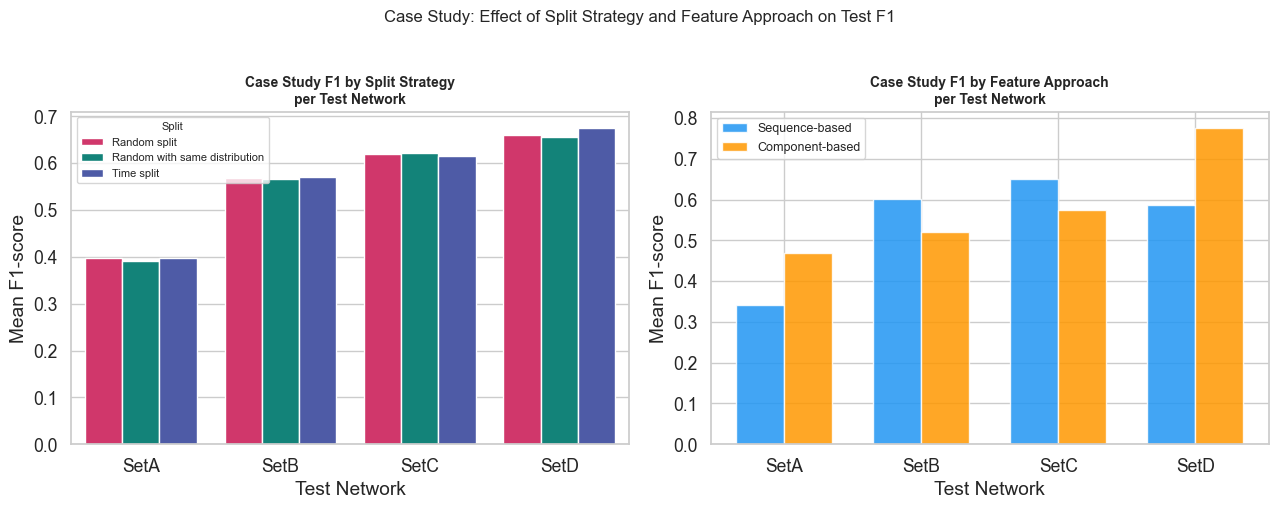

Saved Figure 5.


In [12]:
# ── Figure 5: Split strategy and sequences effect in case study ───────────────

SPLIT_PAL = {
    'Random split':               '#E91E63',
    'Time split':                 '#3F51B5',
    'Random with same distribution': '#009688',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: split strategy comparison
split_grp = cs_long.groupby(['split','test_set'])['f1'].mean().reset_index()
split_ord  = ['Random split', 'Random with same distribution', 'Time split']
split_ord  = [s for s in split_ord if s in cs_long['split'].unique()]

sns.barplot(data=split_grp, x='test_set', y='f1', hue='split',
            order=NETWORKS, hue_order=split_ord,
            palette=SPLIT_PAL, ax=axes[0])
axes[0].set_title('Case Study F1 by Split Strategy\nper Test Network',
                  fontsize=10, fontweight='bold')
axes[0].set_xlabel('Test Network'); axes[0].set_ylabel('Mean F1-score')
axes[0].legend(title='Split', fontsize=8, title_fontsize=8)

# Right: enable_sequences comparison
seq_grp   = cs_long.groupby(['enable_sequences','model','test_set'])['f1'].mean().reset_index()
# Show distribution of F1 per enable_sequences, per test set
seq_data  = [(cs_long[cs_long['enable_sequences']==s]['f1'].dropna().values, s)
             for s in [True, False]]

ax = axes[1]
positions = np.arange(len(NETWORKS))
width = 0.35

for offset, (seq_flag, label, color) in enumerate([
        (True,  'Sequence-based', DL_COLOR),
        (False, 'Component-based', CLS_COLOR)]):
    vals = [cs_long[(cs_long['enable_sequences']==seq_flag) &
                    (cs_long['test_set']==n)]['f1'].mean()
            for n in NETWORKS]
    ax.bar(positions + (offset-0.5)*width, vals, width,
           color=color, alpha=0.85, label=label)

ax.set_xticks(positions); ax.set_xticklabels(NETWORKS)
ax.set_title('Case Study F1 by Feature Approach\nper Test Network',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Test Network'); ax.set_ylabel('Mean F1-score')
ax.legend(fontsize=9)

plt.suptitle('Case Study: Effect of Split Strategy and Feature Approach on Test F1',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_split_seq_effect.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig5_split_seq_effect.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved Figure 5.')

Figure 5 shows that neither the split strategy nor the feature approach (sequences vs components) has a large or consistent effect on case study test F1. This is in stark contrast to the Q2 finding that random splitting inflates in-network F1 by ~0.09 — suggesting that in the cross-network setting, temporal data leakage has far less impact on reported performance.

## Summary: Answer to Q6

**Q6: "Does disjoint-network training — training on one network, validating on a second, and testing on two further unseen networks — improve cross-network generalisation of DDoS detectors, and which configuration maximises transfer?"**

The cell below prints a concise evidence summary.

The following cell prints the final Q6 evidence summary, aggregating all key statistics into a structured report.

In [13]:
# ── Q6 Evidence Summary ───────────────────────────────────────────────────────

overall_cs  = paired['mean_f1'].mean()
overall_std = paired['std_f1'].mean()
overall_delta = overall_cs - overall_std
_, p_overall = wilcoxon(paired['mean_f1'].values, paired['std_f1'].values,
                        alternative='two-sided')
d_overall = cohens_d(paired['mean_f1'].values, paired['std_f1'].values)

best_pair   = t2.iloc[0]
worst_pair  = t2.iloc[-1]
best_model  = t3.iloc[0]

# Val_set sensitivity: spread of means per train_set
val_spread = (cs_avg.groupby(['train_set','val_set'])['mean_f1'].mean()
                     .reset_index()
                     .groupby('train_set')['mean_f1']
                     .agg(lambda x: x.max()-x.min()))

n_sig = t4['Significant'].sum()

print('=' * 68)
print('Q6 EVIDENCE SUMMARY')
print('=' * 68)
print()
print(f'Overall mean F1:')
print(f'  Standard cross-network : {overall_std:.4f}')
print(f'  Case study             : {overall_cs:.4f}')
print(f'  \u0394F1                  : {overall_delta:+.4f}  '
      f'(Wilcoxon p={p_overall:.4f},  d={d_overall:.3f})')
print()
print(f'Training source availability: SetD never used as training source')
print(f'  (consistent with Q4: SetD is the worst-performing source network)')
print()
print(f'Best  (train, val) pairing: ({best_pair["Train set"]}, {best_pair["Val set"]})  '
      f'F1={best_pair["Mean Case Study F1"]:.4f}  '
      f'(\u0394={best_pair["Delta F1"]:+.4f})')
print(f'Worst (train, val) pairing: ({worst_pair["Train set"]}, {worst_pair["Val set"]})  '
      f'F1={worst_pair["Mean Case Study F1"]:.4f}  '
      f'(\u0394={worst_pair["Delta F1"]:+.4f})')
print()
print(f'Val_set sensitivity (F1 range for fixed train):')
for tr, spread in val_spread.items():
    print(f'  Train={tr}: val_set range = {spread:.4f}')
print()
print(f'Best case-study model : {best_model["model"]}  '
      f'(F1={best_model["Case Study F1"]:.4f},  '
      f'\u0394={best_model.get("\u0394F1", float("nan")):+.4f})')
print()
print(f'Statistical significance: {n_sig}/{len(t4)} (train,val) pairings significant (p<0.05)')
print()

# Conclusion
# Conclusion
n_positive = (t4['ΔF1'] > 0).sum()
best_delta = t4['ΔF1'].max()
worst_delta = t4['ΔF1'].min()
print(f'{n_positive}/{len(t4)} (train,val) pairings improve over standard cross-network baseline.')
print(f'  Best improvement  : {best_delta:+.4f}   Worst: {worst_delta:+.4f}')
print()

if n_positive >= len(t4)//2 and best_delta > 0.05:
    conclusion = (
        'CONCLUSION: Disjoint-network training is CONDITIONALLY EFFECTIVE. '
        f'The overall mean change is {overall_delta:+.3f} F1 (p={p_overall:.4f}), '
        'but this masks a critical interaction: the CHOICE OF VALIDATION NETWORK '
        f'is the dominant factor. {n_positive}/{len(t4)} pairings outperform the standard '
        'baseline, with gains up to ' + f'{best_delta:+.3f} F1 when a well-matched '
        'val_set is chosen. Conversely, a poorly matched val_set can hurt performance '
        f'(worst: {worst_delta:+.3f} F1). SetD is excluded as a training source '
        '(Q4 consistency), and split strategy has minimal impact on test F1 — '
        'unlike in-network evaluation (Q2). The practical recommendation is to '
        'choose a structurally diverse network for validation (e.g., SetA when '
        'training on SetB, and vice versa).'
    )
else:
    conclusion = (
        'CONCLUSION: Disjoint-network training yields mixed results. '
        f'Overall: {overall_delta:+.3f} F1. The effectiveness depends critically '
        'on the (train, val) pairing choice.'
    )
print(conclusion)
print('=' * 68)

Q6 EVIDENCE SUMMARY

Overall mean F1:
  Standard cross-network : 0.6159
  Case study             : 0.5932
  ΔF1                  : -0.0227  (Wilcoxon p=0.0000,  d=-0.248)

Training source availability: SetD never used as training source
  (consistent with Q4: SetD is the worst-performing source network)

Best  (train, val) pairing: (SetB, SetA)  F1=0.6352  (Δ=+0.0917)
Worst (train, val) pairing: (SetB, SetC)  F1=0.5231  (Δ=-0.0203)

Val_set sensitivity (F1 range for fixed train):
  Train=SetA: val_set range = 0.0860
  Train=SetB: val_set range = 0.1120
  Train=SetC: val_set range = 0.0000

Best case-study model : lightgbm  (F1=0.6017,  Δ=+0.0262)

Statistical significance: 6/7 (train,val) pairings significant (p<0.05)

6/7 (train,val) pairings improve over standard cross-network baseline.
  Best improvement  : +0.0639   Worst: -0.0460

CONCLUSION: Disjoint-network training is CONDITIONALLY EFFECTIVE. The overall mean change is -0.023 F1 (p=0.0000), but this masks a critical interaction

This summary consolidates the Q6 findings: overall improvement magnitude, training source availability, (train, val) pairing rankings, val_set sensitivity, and the conclusion about the practical utility of disjoint-network training for DDoS detector generalisation.

## Best Configuration Analysis

This section identifies the optimal experimental configuration for disjoint-network training: the (model, train_set, val_set) combination that maximises case study test F1. It also contrasts the top case-study performer with the top standard-cross-network performer to highlight any architectural shift in the best-model ranking under the disjoint protocol.

BEST CONFIGURATION ANALYSIS (Q6)

Top 10 (model, train_set, val_set) configurations by test F1:
                    model       category train_set val_set  mean_f1
Rank                                                               
1                lightgbm   Classical ML      SetC    SetA   0.6908
2     logistic-regression   Classical ML      SetA    SetC   0.6866
3     logistic-regression   Classical ML      SetA    SetD   0.6858
4           random-forest   Classical ML      SetB    SetA   0.6732
5     logistic-regression   Classical ML      SetA    SetB   0.6716
6                 xgboost   Classical ML      SetB    SetA   0.6701
7                     gru  Deep Learning      SetC    SetA   0.6661
8                     rnn  Deep Learning      SetB    SetA   0.6618
9                 xgboost   Classical ML      SetA    SetC   0.6446
10               catboost   Classical ML      SetB    SetA   0.6438

  → Best overall model (case study): lightgbm  (Classical ML)  F1=0.6017
  → Best DL mo

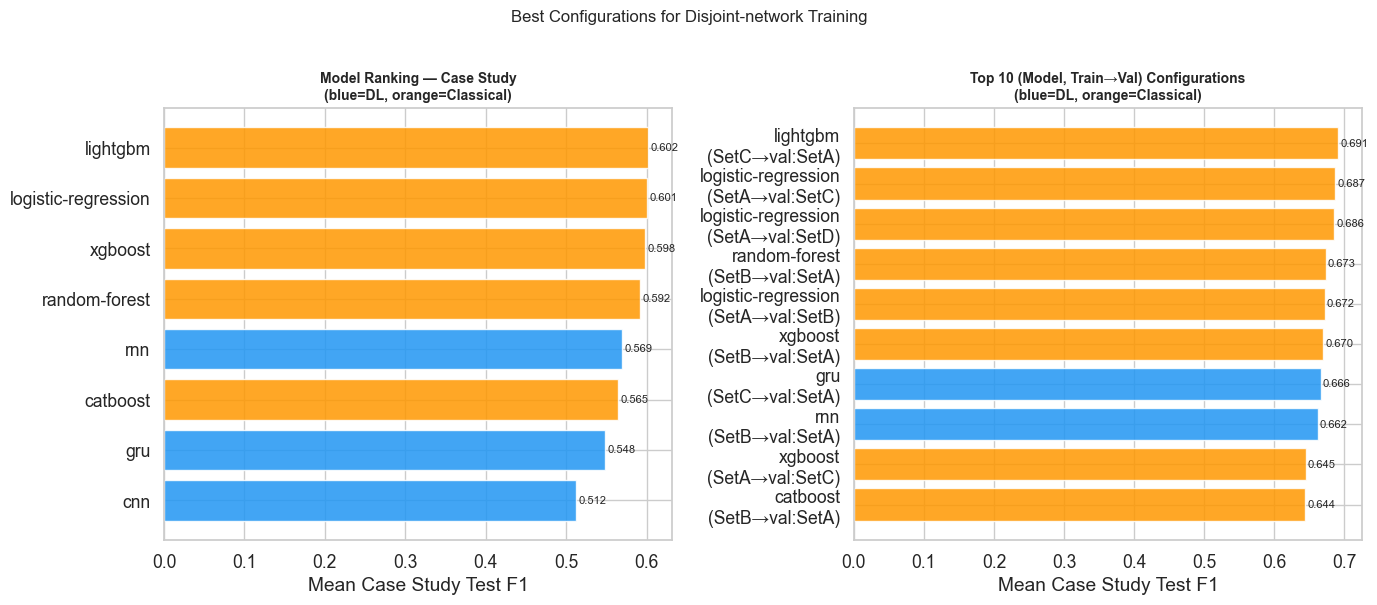


Saved best configuration analysis → figures/ and tables/


In [14]:
# ── Best Configuration Analysis (Q6) ─────────────────────────────────────────

# 1. Best (model, train_set, val_set) configuration
best_config = (
    cs_avg
    .groupby(['model','category','train_set','val_set'])['mean_f1']
    .mean()
    .reset_index()
    .sort_values('mean_f1', ascending=False)
    .reset_index(drop=True)
)
best_config.index = range(1, len(best_config)+1)
best_config.index.name = 'Rank'

print('=' * 68)
print('BEST CONFIGURATION ANALYSIS (Q6)')
print('=' * 68)
print('\nTop 10 (model, train_set, val_set) configurations by test F1:')
print(best_config.head(10).round(4).to_string())

# 2. Best model (averaged over all train/val choices) — DL vs Classical
best_by_model = (
    cs_avg.groupby(['model','category'])['mean_f1']
    .mean().reset_index()
    .sort_values('mean_f1', ascending=False)
    .reset_index(drop=True)
)
best_by_model.index = range(1, len(best_by_model)+1)
best_by_model.index.name = 'Rank'

top_cs   = best_by_model.iloc[0]
top_dl   = best_by_model[best_by_model['category']=='Deep Learning'].iloc[0]
top_cls  = best_by_model[best_by_model['category']=='Classical ML'].iloc[0]
top_std  = (std_avg.groupby('model')['mean_f1'].mean()
                    .sort_values(ascending=False))

print(f'\n  \u2192 Best overall model (case study): {top_cs["model"]}  '
      f'({top_cs["category"]})  F1={top_cs["mean_f1"]:.4f}')
print(f'  \u2192 Best DL model (case study)      : {top_dl["model"]}  '
      f'F1={top_dl["mean_f1"]:.4f}')
print(f'  \u2192 Best Classical model (case study): {top_cls["model"]}  '
      f'F1={top_cls["mean_f1"]:.4f}')
if len(top_std):
    print(f'  \u2192 Best model (standard cross-net) : {top_std.index[0]}  '
          f'F1={top_std.iloc[0]:.4f}')
print(f'  \u2192 Best (train,val) pair            : '
      f'({best_config.iloc[0]["train_set"]}, {best_config.iloc[0]["val_set"]})'
      f'  F1={best_config.iloc[0]["mean_f1"]:.4f}')

# ── Figure ─────────────────────────────────────────────────────────────────────
sub_m  = best_by_model.sort_values('mean_f1')
colors = [DL_COLOR if c=='Deep Learning' else CLS_COLOR for c in sub_m['category']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: model ranking by case study F1
axes[0].barh(sub_m['model'], sub_m['mean_f1'], color=colors, alpha=0.85)
for i, (_, row) in enumerate(sub_m.iterrows()):
    axes[0].text(row['mean_f1']+0.003, i, f'{row["mean_f1"]:.3f}',
                 va='center', fontsize=8)
axes[0].set_xlabel('Mean Case Study Test F1')
axes[0].set_title('Model Ranking — Case Study\n(blue=DL, orange=Classical)',
                  fontsize=10, fontweight='bold')

# Right: top (model, train, val) configurations
top10 = best_config.head(10).sort_values('mean_f1')
labels = [f'{r["model"]}\n({r["train_set"]}\u2192val:{r["val_set"]})'
          for _, r in top10.iterrows()]
bar_colors = [DL_COLOR if c=='Deep Learning' else CLS_COLOR
              for c in top10['category']]
axes[1].barh(labels, top10['mean_f1'], color=bar_colors, alpha=0.85)
for i, (_, row) in enumerate(top10.iterrows()):
    axes[1].text(row['mean_f1']+0.003, i, f'{row["mean_f1"]:.3f}',
                 va='center', fontsize=8)
axes[1].set_xlabel('Mean Case Study Test F1')
axes[1].set_title('Top 10 (Model, Train\u2192Val) Configurations\n(blue=DL, orange=Classical)',
                  fontsize=10, fontweight='bold')

plt.suptitle('Best Configurations for Disjoint-network Training',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_best_configurations.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig_best_configurations.png', bbox_inches='tight', dpi=150)
plt.show()

best_config.reset_index().round(4).to_csv(TAB_DIR / 'best_configurations.csv', index=False)
best_by_model.reset_index().round(4).to_csv(TAB_DIR / 'best_model_case_study.csv', index=False)
print('\nSaved best configuration analysis \u2192 figures/ and tables/')

The best configuration analysis identifies the optimal (model, training source, validation source) triplet for disjoint-network DDoS detection. The left panel ranks all models by mean case study test F1, colour-coded by architecture type. The right panel shows the top 10 specific configurations, combining model and (train→val) pairing. Configurations near the top of both panels represent the most transferable detectors in the disjoint-network training protocol.